<a href="https://colab.research.google.com/github/AkankshaB123/forecasting/blob/main/Time_Series_Forecasting_with_XGBoost_To_predict_hourly_energy_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from seaborn.palettes import color_palette
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
color_palette = sns.color_palette()
plt.style.use('fivethirtyeight')

## Different Time-Series
* No Recognizable Patterns - Purely Random Error
* Quadratic, Exponential (eg. Stock market)
* Increasing linear trend
* Seasonal Pattern
* Seasonal Pattern + Linear Growth (Combination of any of above)

In [50]:
df = pd.read_csv("/content/sample_data/PJME_hourly 2.csv")
df.head(3)

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0


In [51]:
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


## x-axis of plot will look neat/not as string with below 2 commands

In [52]:
df.set_index('Datetime', inplace = True)
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [53]:
df.index = pd.to_datetime(df.index)

# PJME Energy Use - EDA

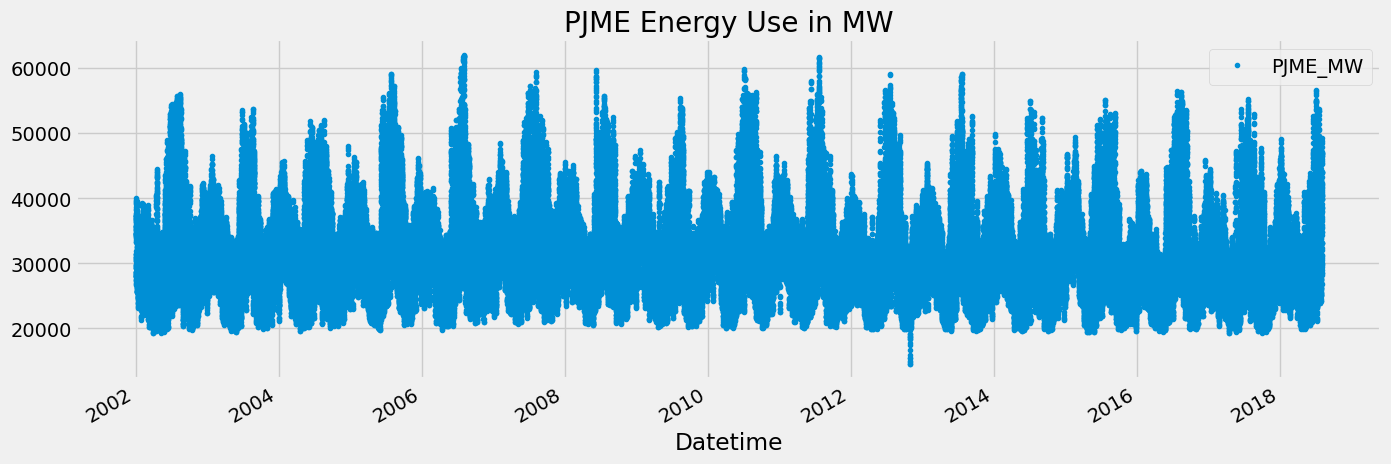

In [54]:
df.plot(style='.',
        figsize=(15,5),
        title='PJME Energy Use in MW')
plt.show()

# Train/Test Split
Exclude: Cross-Validation, Hyper-parameter tuning

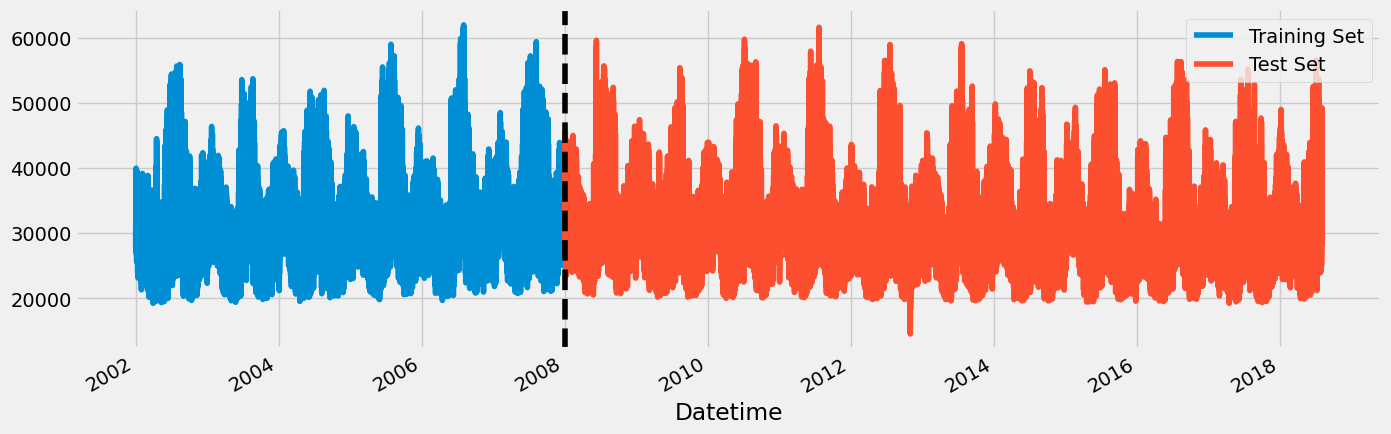

In [55]:
train = df.loc[df.index < '01-01-2008']
test = df.loc[df.index >= '01-01-2008']

fig, ax = plt.subplots(figsize = (15,5))
train.plot(ax=ax, label = 'Training Set')
test.plot(ax=ax, label = 'Test Set')
ax.legend(['Training Set', 'Test Set'])
ax.axvline('01-01-2008', color = 'black', ls = '--')
plt.show()

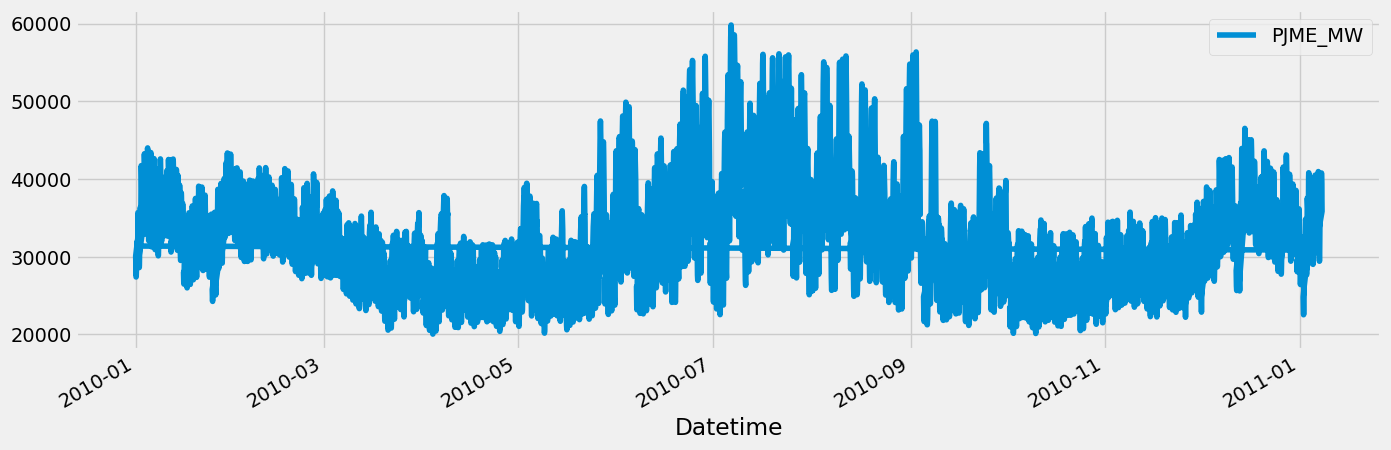

In [56]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2011')].plot(figsize = (15,5))
plt.show()

* Identify peaks, valleys and weekend effect

# Feature Creation

In [57]:
def create_features(df):

  df['hour'] = df.index.hour
  df['dayofweek'] = df.index.dayofweek
  df['quarter'] = df.index.quarter
  df['month'] = df.index.month
  df['year'] = df.index.year
  df['dayofyear'] = df.index.dayofyear
  return df

df = create_features(df)

# Visualize our Feature/Target Relationship

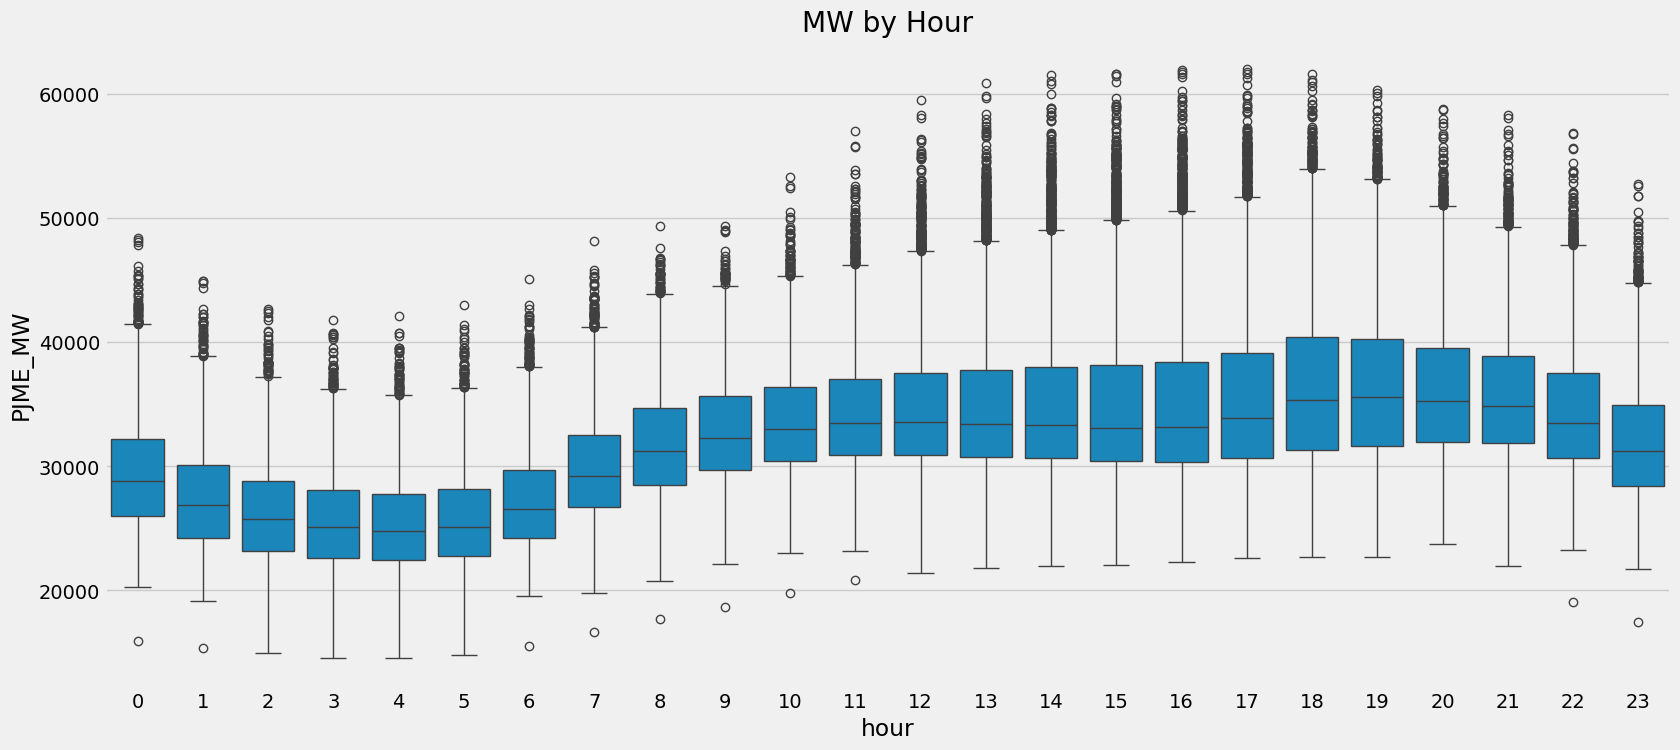

In [58]:
fig, ax = plt.subplots(figsize = (18,8))
sns.boxplot(x = 'hour',
            y = 'PJME_MW',
            data = df)
ax.set_title('MW by Hour')
plt.show()

Observation:
* Early in the morning dip in energy use
* Later higher

/tmp/ipython-input-2360374919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'month',


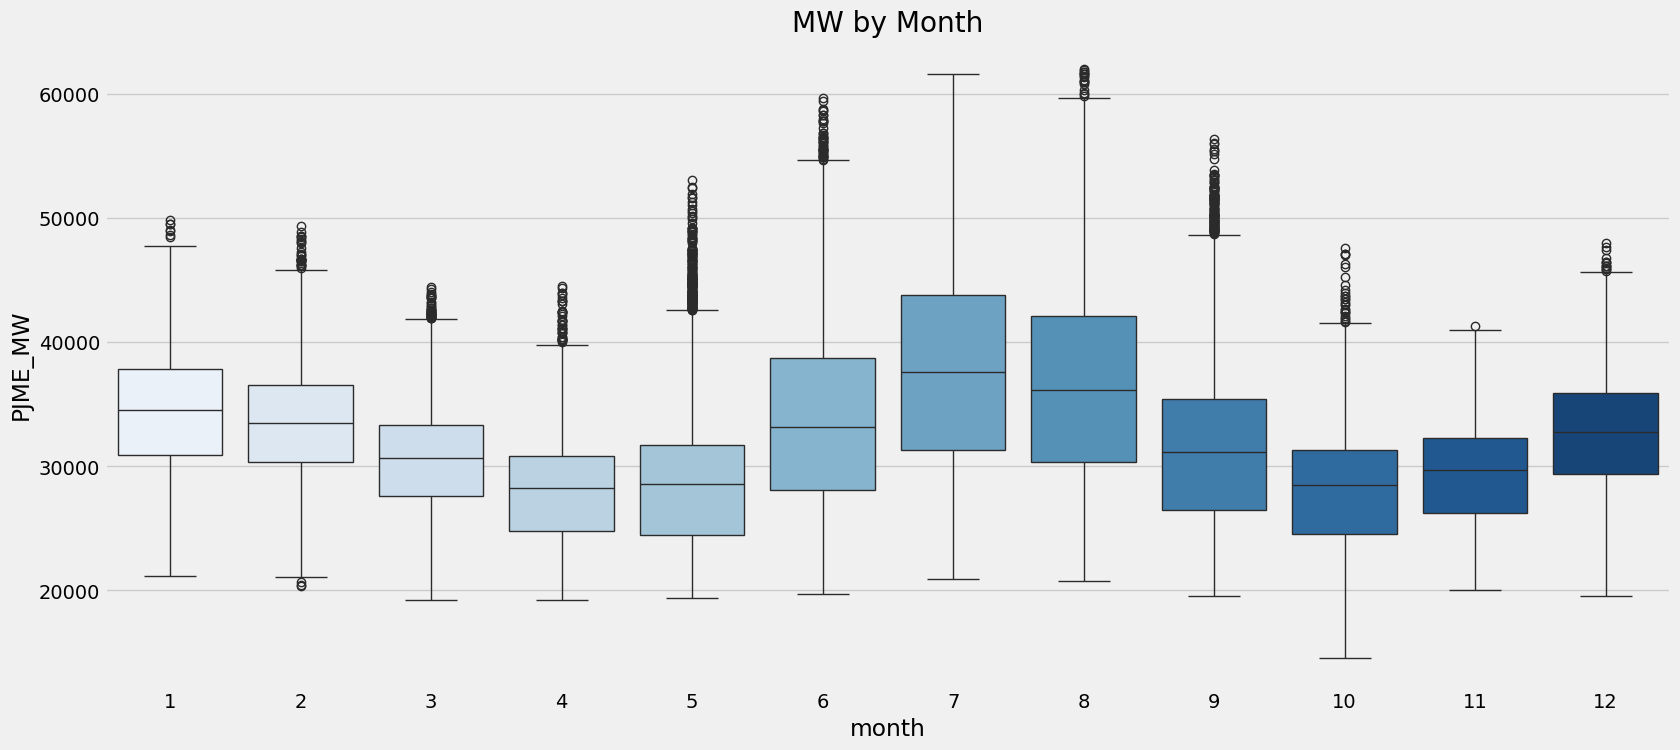

In [59]:
fig, ax = plt.subplots(figsize = (18,8))
sns.boxplot(x = 'month',
            y = 'PJME_MW',
            palette = 'Blues',
            data = df)
ax.set_title('MW by Month')
plt.show()

Observation
* Peak in 2 times (Winter season)
* Fall & Spring has lower
* Another peak in summer

# Create our Model

In [ ]:
train = create_features(train)
test = create_features(test)

FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year','dayofyear']
TARGET = 'PJME_MW'

In [60]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [62]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [65]:
reg = xgb.XGBRegressor(n_estimators = 1000, early_stopping_rounds = 50, learning_rate = 0.001)
reg.fit(X_train, y_train,
        eval_set = [(X_train, y_train), (X_test, y_test)],
        verbose = 100)

[0]	validation_0-rmse:6494.49799	validation_1-rmse:6458.69860
[100]	validation_0-rmse:6052.69454	validation_1-rmse:6047.73302
[200]	validation_0-rmse:5665.00749	validation_1-rmse:5690.70712
[300]	validation_0-rmse:5324.68109	validation_1-rmse:5383.67849
[400]	validation_0-rmse:5025.86196	validation_1-rmse:5117.26045
[500]	validation_0-rmse:4763.81386	validation_1-rmse:4888.95513
[600]	validation_0-rmse:4528.93319	validation_1-rmse:4690.40129
[700]	validation_0-rmse:4324.83112	validation_1-rmse:4521.85070
[800]	validation_0-rmse:4147.44493	validation_1-rmse:4382.43436
[900]	validation_0-rmse:3991.94941	validation_1-rmse:4266.11700
[999]	validation_0-rmse:3856.70245	validation_1-rmse:4168.01818


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# Forecast on Test

In [68]:
test['prediction'] = reg.predict(X_test)

/tmp/ipython-input-2903689382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(X_test)


In [74]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test['prediction'], how = 'left', left_index = True, right_index = True)

/tmp/ipython-input-2477620079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(X_test)


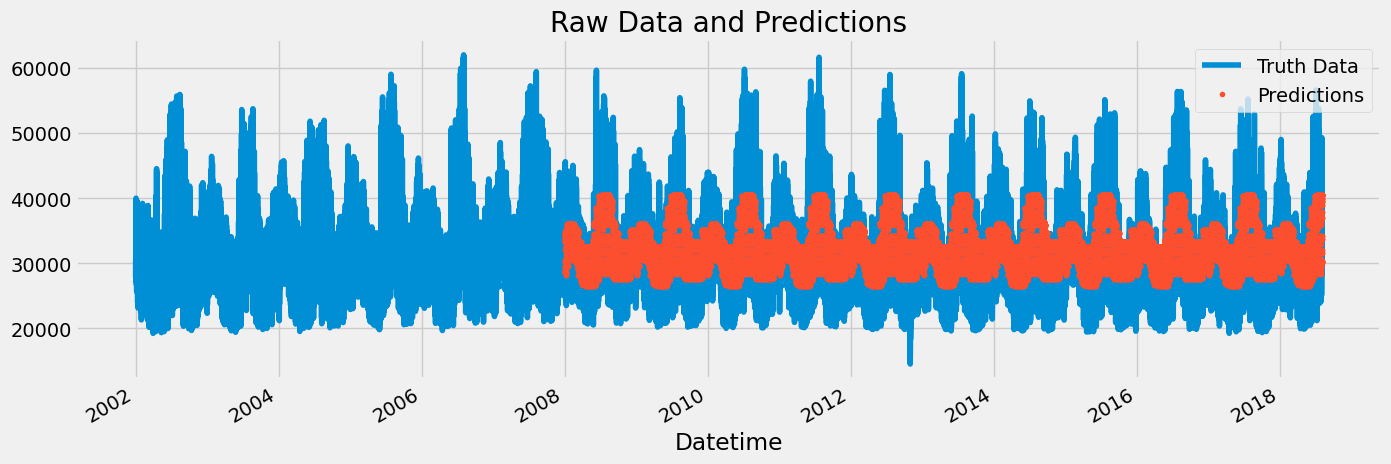

In [76]:
ax = df[['PJME_MW']].plot(figsize = (15,5))
df['prediction'].plot(ax = ax, style = '.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Predictions')
plt.show()

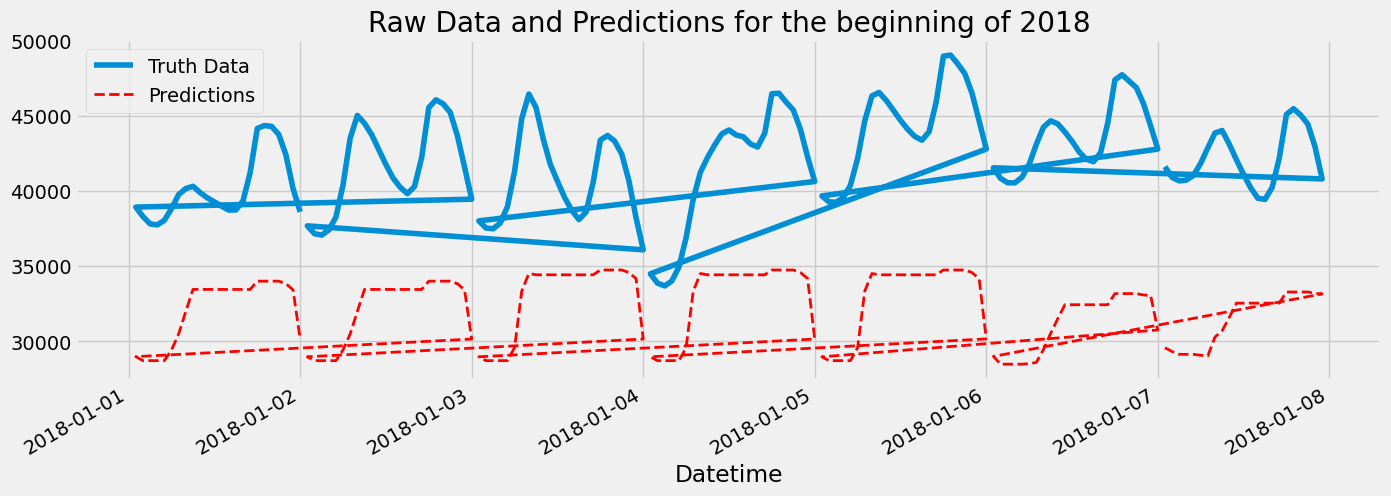

In [93]:
ax = df.loc[(df.index > '01-01-2018') & (df.index < '01-08-2018')]['PJME_MW']\
    .plot(figsize = (15,5))
df.loc[(df.index > '01-01-2018') & (df.index < '01-08-2018')]['prediction']\
    .plot(ax = ax, style = '--', color = 'red', linewidth = 2)
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Predictions for the beginning of 2018')
plt.show()

In [84]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score: 0.2f}')

RMSE Score on Test set:  4168.02


# Calculate Error

In [87]:
test['error'] = np.abs(test[TARGET] - test['prediction'])

/tmp/ipython-input-1709595864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = np.abs(test[TARGET] - test['prediction'])


In [88]:
test['date'] = test.index.date

/tmp/ipython-input-2096088089.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['date'] = test.index.date


Worst predicted dates

In [90]:
test.groupby('date')['error'].mean().sort_values(ascending = False).head(5)

,error
date,
2011-07-22,15322.169922
2011-07-23,13818.370768
2008-06-10,12849.911540
2010-07-24,12606.287435
2013-07-19,12605.711589


Best Predictions

In [91]:
test.groupby('date')['error'].mean().sort_values(ascending = True).head(5)

,error
date,
2018-04-03,770.239909
2013-03-28,779.928548
2010-08-18,789.894613
2014-02-14,796.897949
2008-03-28,837.340983
